In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
excel_file = pd.ExcelFile("/content/marketing_dataset.xlsx")
excel_file.sheet_names

['Campaign_Data', 'Campaigns', 'Channels', 'Leads']

In [ ]:
campaign_df = pd.read_excel("/content/marketing_dataset.xlsx", sheet_name = "Campaign_Data")
campaigns_df = pd.read_excel("/content/marketing_dataset.xlsx", sheet_name = "Campaigns")
channels_df = pd.read_excel("/content/marketing_dataset.xlsx", sheet_name = "Channels")
leads_df = pd.read_excel("/content/marketing_dataset.xlsx", sheet_name = "Leads")

# Sheet 1: Campaign_Data


In [ ]:
campaign_df.head()

,Campaign_ID,Date,Campaign_Name,Channel,Region,Impressions,Clicks,Spend,Conversions,Revenue,Device
0,CMP969,2025-02-04 09:07:00,Ramadan offer,Instagram,Mansoura,40006.0,3692,8800,238,35274,Tablet
1,CMP603,2023-02-05 21:47:00,Ramadan Offer,Google Ads,Cairo,22122.0,1804,5787,486,27702,Desktop
2,CMP143,2024-11-11 06:28:00,Summer Sale,Google Ads,Alex,26503.0,413,6662,85,13820,Desktop
3,CMP317,2025-04-07 19:28:00,Ramadan Offer,Google Ads,Alex,27677.0,3444,8526,36,6120,Tablet
4,CMP450,2024-04-28 00:42:00,Discount Blast,Google Ads,Tanta,21657.0,3696,7632,966,80158,Mobile


In [ ]:
campaign_df.shape

(3000, 11)

In [ ]:
campaign_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Campaign_ID    3000 non-null   object        
 1   Date           3000 non-null   datetime64[ns]
 2   Campaign_Name  3000 non-null   object        
 3   Channel        3000 non-null   object        
 4   Region         2519 non-null   object        
 5   Impressions    2940 non-null   float64       
 6   Clicks         3000 non-null   int64         
 7   Spend          3000 non-null   int64         
 8   Conversions    3000 non-null   int64         
 9   Revenue        3000 non-null   int64         
 10  Device         3000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 257.9+ KB


In [ ]:
campaign_df.isnull().sum()

,0
Campaign_ID,0
Date,0
Campaign_Name,0
Channel,0
Region,481
Impressions,60
Clicks,0
Spend,0
Conversions,0
Revenue,0


In [ ]:
campaign_df.duplicated().sum()

np.int64(0)

In [ ]:
campaign_df.columns

Index(['Campaign_ID', 'Date', 'Campaign_Name', 'Channel', 'Region',
       'Impressions', 'Clicks', 'Spend', 'Conversions', 'Revenue', 'Device'],
      dtype='object')

In [ ]:
col = ['Campaign_Name', 'Channel', 'Region', 'Device']

for i in col:
  print("\n")
  print(campaign_df[i].value_counts(dropna = False))



Campaign_Name
Ramadan offer     454
Ramadan Offer     443
Summer Sale       439
Black Friday      419
New Launch        416
summer sale       415
Discount Blast    414
Name: count, dtype: int64


Channel
Email         450
TikTok        449
GOOGLE ADS    437
facebook      430
Google Ads    430
Instagram     415
Facebook      389
Name: count, dtype: int64


Region
Alex        527
Cairo       521
Mansoura    515
Tanta       499
NaN         481
Cairo       457
Name: count, dtype: int64


Device
Tablet     1010
Mobile      999
Desktop     991
Name: count, dtype: int64


In [ ]:
fix_col = ['Campaign_Name', 'Channel', 'Region']

for col in fix_col:
  campaign_df[col] = campaign_df[col].str.strip().str.title()

for col in fix_col:
  print("\n")
  print(campaign_df[col].value_counts(dropna = False))



Campaign_Name
Ramadan Offer     897
Summer Sale       854
Black Friday      419
New Launch        416
Discount Blast    414
Name: count, dtype: int64


Channel
Google Ads    867
Facebook      819
Email         450
Tiktok        449
Instagram     415
Name: count, dtype: int64


Region
Cairo       978
Alex        527
Mansoura    515
Tanta       499
NaN         481
Name: count, dtype: int64


In [ ]:
col = ['Campaign_Name', 'Channel', 'Region', 'Device']

for i in col:
  print("\n")
  print(campaign_df[i].value_counts(dropna = False))



Campaign_Name
Ramadan Offer     897
Summer Sale       854
Black Friday      419
New Launch        416
Discount Blast    414
Name: count, dtype: int64


Channel
Google Ads    867
Facebook      819
Email         450
Tiktok        449
Instagram     415
Name: count, dtype: int64


Region
Cairo       978
Alex        527
Mansoura    515
Tanta       499
NaN         481
Name: count, dtype: int64


Device
Tablet     1010
Mobile      999
Desktop     991
Name: count, dtype: int64


In [ ]:
campaign_df['Date']

,Date
0,2025-02-04 09:07:00
1,2023-02-05 21:47:00
2,2024-11-11 06:28:00
3,2025-04-07 19:28:00
4,2024-04-28 00:42:00
...,...
2995,2023-04-18 20:19:00
2996,2025-12-26 14:28:00
2997,2023-06-16 03:42:00
2998,2025-10-10 14:51:00


In [ ]:
campaign_df['Date'] = pd.to_datetime(campaign_df['Date'], errors='coerce')

campaign_df['Year'] = campaign_df['Date'].dt.year
campaign_df['Month'] = campaign_df['Date'].dt.month
campaign_df['Day'] = campaign_df['Date'].dt.day
campaign_df['Time'] = campaign_df['Date'].dt.time
campaign_df['Date'] = campaign_df['Date'].dt.date

In [ ]:
campaign_df[['Date', 'Year', 'Month', 'Day', 'Time']].head()

,Date,Year,Month,Day,Time
0,2025-02-04,2025,2,4,09:07:00
1,2023-02-05,2023,2,5,21:47:00
2,2024-11-11,2024,11,11,06:28:00
3,2025-04-07,2025,4,7,19:28:00
4,2024-04-28,2024,4,28,00:42:00


In [ ]:
campaign_df

,Campaign_ID,Date,Campaign_Name,Channel,Region,Impressions,Clicks,Spend,Conversions,Revenue,Device,Year,Month,Day,Time
0,CMP969,2025-02-04,Ramadan Offer,Instagram,Mansoura,40006.0,3692,8800,238,35274,Tablet,2025,2,4,09:07:00
1,CMP603,2023-02-05,Ramadan Offer,Google Ads,Cairo,22122.0,1804,5787,486,27702,Desktop,2023,2,5,21:47:00
2,CMP143,2024-11-11,Summer Sale,Google Ads,Alex,26503.0,413,6662,85,13820,Desktop,2024,11,11,06:28:00
3,CMP317,2025-04-07,Ramadan Offer,Google Ads,Alex,27677.0,3444,8526,36,6120,Tablet,2025,4,7,19:28:00
4,CMP450,2024-04-28,Discount Blast,Google Ads,Tanta,21657.0,3696,7632,966,80158,Mobile,2024,4,28,00:42:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,CMP152,2023-04-18,Black Friday,Tiktok,Cairo,41996.0,848,8087,97,12028,Desktop,2023,4,18,20:19:00
2996,CMP509,2025-12-26,Summer Sale,Tiktok,Cairo,32725.0,3202,2013,923,177196,Mobile,2025,12,26,14:28:00
2997,CMP189,2023-06-16,Ramadan Offer,Email,Alex,33677.0,4906,4509,1490,241430,Mobile,2023,6,16,03:42:00
2998,CMP906,2025-10-10,Discount Blast,Instagram,Cairo,4961.0,861,9052,54,4030,Tablet,2025,10,10,14:51:00


In [ ]:
# fix null values: Region/ Impressions
campaign_df[campaign_df['Region'].isnull()]

,Campaign_ID,Date,Campaign_Name,Channel,Region,Impressions,Clicks,Spend,Conversions,Revenue,Device,Year,Month,Day,Time
5,CMP585,2024-09-08,New Launch,Instagram,NaN,46753.0,7990,8703,1934,210806,Mobile,2024,9,8,20:40:00
20,CMP471,2025-05-08,Discount Blast,Google Ads,NaN,23620.0,493,6059,96,18866,Tablet,2025,5,8,10:36:00
26,CMP525,2023-09-21,Summer Sale,Tiktok,NaN,36742.0,666,5388,135,13770,Tablet,2023,9,21,20:45:00
31,CMP492,2025-09-12,Summer Sale,Google Ads,NaN,15308.0,1887,2930,62,12256,Mobile,2025,9,12,03:33:00
33,CMP946,2023-05-22,New Launch,Facebook,NaN,40553.0,5900,6527,480,89260,Tablet,2023,5,22,15:52:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2947,CMP605,2025-09-07,Ramadan Offer,Facebook,NaN,13367.0,694,909,230,13340,Desktop,2025,9,7,01:44:00
2959,CMP188,2024-02-23,Discount Blast,Facebook,NaN,33086.0,2538,7215,94,8322,Mobile,2024,2,23,05:00:00
2963,CMP246,2024-07-11,Summer Sale,Google Ads,NaN,39098.0,6499,3070,916,143792,Desktop,2024,7,11,02:40:00
2967,CMP615,2025-08-11,Discount Blast,Facebook,NaN,29694.0,3342,5941,341,29647,Tablet,2025,8,11,09:49:00


In [ ]:
campaign_df['Region'] = campaign_df['Region'].fillna('Unknown')

In [ ]:
campaign_df['Region'].isnull().sum()

np.int64(0)

In [ ]:
# Impression null values
campaign_df[campaign_df['Impressions'].isnull()].head()

,Campaign_ID,Date,Campaign_Name,Channel,Region,Impressions,Clicks,Spend,Conversions,Revenue,Device,Year,Month,Day,Time
34,CMP238,2023-01-15,Ramadan Offer,Google Ads,Alex,NaN,1624,5151,420,49540,Tablet,2023,1,15,20:07:00
137,CMP598,2024-10-10,Discount Blast,Email,Cairo,NaN,9692,5204,484,69212,Mobile,2024,10,10,22:04:00
143,CMP132,2025-02-17,New Launch,Google Ads,Unknown,NaN,2033,2346,368,68796,Tablet,2025,2,17,17:53:00
146,CMP793,2023-11-28,Summer Sale,Facebook,Cairo,NaN,1328,768,332,28934,Desktop,2023,11,28,04:51:00
155,CMP876,2023-01-23,Summer Sale,Email,Tanta,NaN,684,1363,158,14112,Tablet,2023,1,23,12:41:00


In [ ]:
# Fill missing Impressions with the median because the median is less affected by extreme values
campaign_df['Impressions'] = campaign_df['Impressions'].fillna(campaign_df['Impressions'].median())

In [ ]:
campaign_df['Impressions'].isnull().sum()

np.int64(0)

In [ ]:
# check for impossible values
campaign_df.describe()

,Impressions,Clicks,Spend,Conversions,Revenue,Year,Month,Day
count,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,24944.505667,2490.417667,5028.987667,415.86100,51612.782667,2024.002333,6.574667,15.558333
std,13914.326909,2136.727254,2903.542184,489.94365,65942.802306,0.820499,3.442825,8.802410
min,1017.000000,51.000000,100.000000,0.00000,-20.000000,2023.000000,1.000000,1.000000
25%,12861.750000,748.500000,2419.250000,70.75000,8412.500000,2023.000000,4.000000,8.000000
50%,24733.000000,1873.500000,5046.000000,228.50000,27598.500000,2024.000000,7.000000,16.000000
75%,36783.000000,3822.500000,7575.000000,567.25000,66715.500000,2025.000000,10.000000,23.000000
max,49996.000000,9692.000000,9994.000000,3134.00000,617378.000000,2025.000000,12.000000,31.000000


In [ ]:
#Negative value in Revenue
campaign_df[campaign_df['Revenue'] == -20]

,Campaign_ID,Date,Campaign_Name,Channel,Region,Impressions,Clicks,Spend,Conversions,Revenue,Device,Year,Month,Day,Time
212,CMP583,2025-04-04,Black Friday,Google Ads,Cairo,14188.0,185,809,0,-20,Tablet,2025,4,4,08:40:00
687,CMP755,2024-10-28,Summer Sale,Facebook,Alex,4757.0,136,9665,0,-20,Mobile,2024,10,28,06:51:00
1507,CMP381,2024-06-10,Black Friday,Facebook,Alex,16165.0,125,242,0,-20,Mobile,2024,6,10,18:09:00
1877,CMP222,2024-03-03,Black Friday,Facebook,Mansoura,1359.0,82,1949,0,-20,Desktop,2024,3,3,22:59:00
2132,CMP580,2023-06-08,Summer Sale,Facebook,Alex,37301.0,538,2449,0,-20,Tablet,2023,6,8,15:36:00
2214,CMP916,2025-07-18,Summer Sale,Facebook,Cairo,11415.0,531,7547,0,-20,Mobile,2025,7,18,07:48:00
2259,CMP986,2024-09-26,Ramadan Offer,Tiktok,Unknown,49595.0,1179,3652,0,-20,Mobile,2024,9,26,00:52:00


In [ ]:
campaign_df.loc[campaign_df['Revenue'] == -20, 'Revenue'] = 0

In [ ]:
#check again
campaign_df[campaign_df['Revenue'] == -20]

,Campaign_ID,Date,Campaign_Name,Channel,Region,Impressions,Clicks,Spend,Conversions,Revenue,Device,Year,Month,Day,Time


In [ ]:
#Check for Outliers
campaign_df[["Impressions", "Clicks", "Spend", "Conversions", "Revenue"]].describe()

,Impressions,Clicks,Spend,Conversions,Revenue
count,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000
mean,24944.505667,2490.417667,5028.987667,415.86100,51612.829333
std,13914.326909,2136.727254,2903.542184,489.94365,65942.765761
min,1017.000000,51.000000,100.000000,0.00000,0.000000
25%,12861.750000,748.500000,2419.250000,70.75000,8412.500000
50%,24733.000000,1873.500000,5046.000000,228.50000,27598.500000
75%,36783.000000,3822.500000,7575.000000,567.25000,66715.500000
max,49996.000000,9692.000000,9994.000000,3134.00000,617378.000000


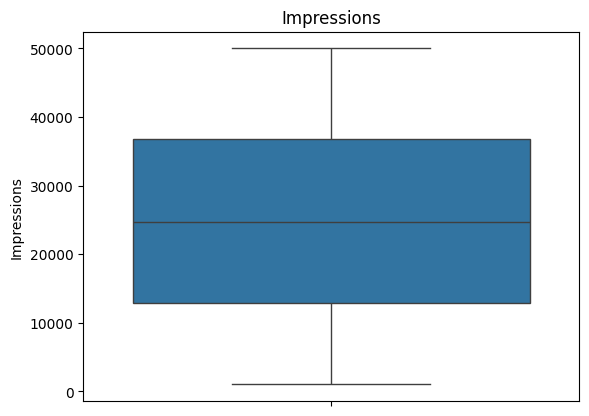

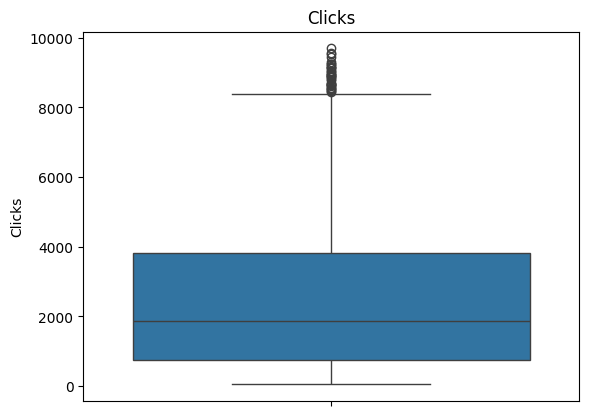

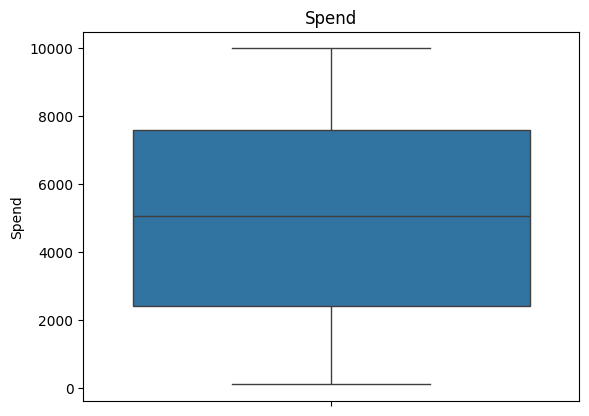

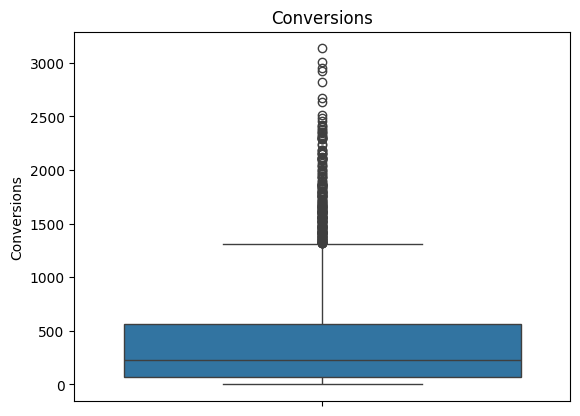

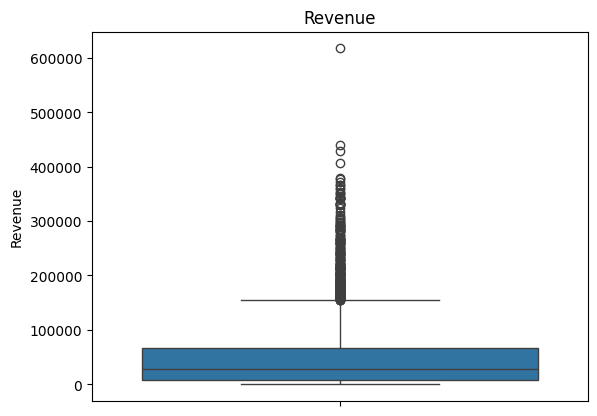

In [ ]:
sns.boxplot(y=campaign_df['Impressions'])
plt.title('Impressions')
plt.show()

sns.boxplot(y=campaign_df['Clicks'])
plt.title('Clicks')
plt.show()

sns.boxplot(y=campaign_df['Spend'])
plt.title('Spend')
plt.show()

sns.boxplot(y=campaign_df['Conversions'])
plt.title('Conversions')
plt.show()

sns.boxplot(y=campaign_df['Revenue'])
plt.title('Revenue')
plt.show()

In [ ]:
#Check if the outlier in Clicks,Conversions,Revenue makes sense or must be removed
#Revenue
Q1 = campaign_df["Revenue"].quantile(0.25)
Q3 = campaign_df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

revenue_outliers = campaign_df[(campaign_df['Revenue'] < lower) | (campaign_df['Revenue'] > upper)]
revenue_outliers
#High Revenue values are paired with high Conversions, so they look plausible.

,Campaign_ID,Date,Campaign_Name,Channel,Region,Impressions,Clicks,Spend,Conversions,Revenue,Device,Year,Month,Day,Time
5,CMP585,2024-09-08,New Launch,Instagram,Unknown,46753.0,7990,8703,1934,210806,Mobile,2024,9,8,20:40:00
71,CMP794,2025-05-31,Summer Sale,Instagram,Cairo,28802.0,5031,4639,1661,269132,Mobile,2025,5,31,09:47:00
72,CMP209,2025-01-07,New Launch,Facebook,Unknown,31800.0,4467,5091,1184,228492,Mobile,2025,1,7,22:58:00
85,CMP490,2025-01-16,Ramadan Offer,Facebook,Alex,41356.0,6576,267,1834,291656,Tablet,2025,1,16,01:58:00
121,CMP282,2023-10-03,Black Friday,Facebook,Mansoura,24856.0,3961,6064,1096,163354,Tablet,2023,10,3,16:42:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2940,CMP308,2025-04-01,Summer Sale,Tiktok,Cairo,45941.0,8566,309,1323,239443,Desktop,2025,4,1,10:58:00
2957,CMP311,2023-01-27,Ramadan Offer,Instagram,Alex,37394.0,6315,8488,1190,196400,Desktop,2023,1,27,02:59:00
2965,CMP882,2023-05-20,Ramadan Offer,Facebook,Cairo,48998.0,7705,7575,1534,184060,Mobile,2023,5,20,02:00:00
2996,CMP509,2025-12-26,Summer Sale,Tiktok,Cairo,32725.0,3202,2013,923,177196,Mobile,2025,12,26,14:28:00


In [ ]:
#Clicks
Q1 = campaign_df["Clicks"].quantile(0.25)
Q3 = campaign_df["Clicks"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

clicks_outliers = campaign_df[(campaign_df['Clicks'] < lower) | (campaign_df['Clicks'] > upper)]
clicks_outliers
#Also high Imoressions paired with Clicks

,Campaign_ID,Date,Campaign_Name,Channel,Region,Impressions,Clicks,Spend,Conversions,Revenue,Device,Year,Month,Day,Time
18,CMP527,2025-07-25,Black Friday,Instagram,Cairo,43933.0,8641,6660,419,40623,Mobile,2025,7,25,18:30:00
137,CMP598,2024-10-10,Discount Blast,Email,Cairo,24733.0,9692,5204,484,69212,Mobile,2024,10,10,22:04:00
139,CMP955,2023-07-15,Ramadan Offer,Email,Tanta,48867.0,9046,5626,761,89848,Tablet,2023,7,15,14:19:00
178,CMP539,2023-07-21,Discount Blast,Instagram,Alex,48370.0,9552,8082,693,60341,Mobile,2023,7,21,07:46:00
217,CMP351,2024-05-05,New Launch,Facebook,Unknown,49879.0,9451,3621,3134,617378,Desktop,2024,5,5,01:20:00
313,CMP890,2024-10-07,Ramadan Offer,Facebook,Alex,46089.0,8702,4346,2321,211261,Tablet,2024,10,7,20:35:00
411,CMP975,2023-05-26,Ramadan Offer,Facebook,Tanta,47861.0,8470,3430,2173,121738,Tablet,2023,5,26,03:32:00
460,CMP950,2025-05-30,Black Friday,Tiktok,Alex,45178.0,8890,4461,2484,218572,Tablet,2025,5,30,16:28:00
554,CMP771,2024-02-22,Ramadan Offer,Google Ads,Cairo,45448.0,9029,6429,3008,243648,Tablet,2024,2,22,10:19:00
818,CMP980,2024-04-19,Ramadan Offer,Email,Cairo,47721.0,8605,4741,2112,122496,Mobile,2024,4,19,17:27:00


In [ ]:
#Conversions
Q1 = campaign_df["Conversions"].quantile(0.25)
Q3 = campaign_df["Conversions"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

conversions_outliers = campaign_df[(campaign_df['Conversions'] < lower) | (campaign_df['Conversions'] > upper)]
conversions_outliers
#High Clicks paired with high conversions

,Campaign_ID,Date,Campaign_Name,Channel,Region,Impressions,Clicks,Spend,Conversions,Revenue,Device,Year,Month,Day,Time
5,CMP585,2024-09-08,New Launch,Instagram,Unknown,46753.0,7990,8703,1934,210806,Mobile,2024,9,8,20:40:00
71,CMP794,2025-05-31,Summer Sale,Instagram,Cairo,28802.0,5031,4639,1661,269132,Mobile,2025,5,31,09:47:00
85,CMP490,2025-01-16,Ramadan Offer,Facebook,Alex,41356.0,6576,267,1834,291656,Tablet,2025,1,16,01:58:00
120,CMP198,2023-07-02,Summer Sale,Google Ads,Mansoura,24899.0,4444,9345,1332,103876,Tablet,2023,7,2,06:11:00
123,CMP257,2025-10-18,New Launch,Instagram,Mansoura,36759.0,7235,3752,2284,141658,Tablet,2025,10,18,19:06:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2929,CMP253,2025-04-16,Ramadan Offer,Google Ads,Tanta,40813.0,5691,6482,1870,239340,Desktop,2025,4,16,14:39:00
2940,CMP308,2025-04-01,Summer Sale,Tiktok,Cairo,45941.0,8566,309,1323,239443,Desktop,2025,4,1,10:58:00
2956,CMP779,2023-12-01,New Launch,Facebook,Cairo,24733.0,5211,5508,1556,94896,Mobile,2023,12,1,07:11:00
2965,CMP882,2023-05-20,Ramadan Offer,Facebook,Cairo,48998.0,7705,7575,1534,184060,Mobile,2023,5,20,02:00:00


In [ ]:
#They are outliers statistically, but they may still be valid business values.
# “Outliers were detected in Clicks, Conversions, and Revenue using the IQR method.
# After inspection, the extreme values appeared to be consistent with campaign performance, so they were retained rather than removed.”

In [ ]:
# what percentage of impressions became clicks
campaign_df['CTR'] = (campaign_df['Clicks'] / campaign_df['Impressions']) * 100


In [ ]:
# what percentage of clicks became conversions
campaign_df['Conversion_Rate'] = (campaign_df['Conversions'] / campaign_df['Clicks']) * 100

In [ ]:
# how much return the campaign made compared with what was spent
campaign_df["ROI"] = ((campaign_df["Revenue"] - campaign_df["Spend"]) / campaign_df["Spend"]) * 100

In [ ]:
campaign_df["Revenue_per_Conversion"] = (campaign_df["Revenue"] / campaign_df["Conversions"])

In [ ]:
# Which channel generated the most revenue?
campaign_df.groupby("Channel")["Revenue"].sum()

,Revenue
Channel,
Email,22895596
Facebook,42691078
Google Ads,44787544
Instagram,21333859
Tiktok,23130411


In [ ]:
# Which channel has the highest average ROI?
campaign_df.groupby("Channel")["ROI"].mean()

,ROI
Channel,
Email,2132.191497
Facebook,2489.512287
Google Ads,2418.868754
Instagram,2836.458743
Tiktok,2109.263732


In [ ]:
# Which campaign generated the most conversions?
campaign_df.groupby("Campaign_Name")["Conversions"].sum()

,Conversions
Campaign_Name,
Black Friday,175689
Discount Blast,161293
New Launch,167626
Ramadan Offer,388382
Summer Sale,354593


In [ ]:
# Which region generated the most revenue?
campaign_df.groupby("Region")["Revenue"].sum()

,Revenue
Region,
Alex,24222871
Cairo,50967590
Mansoura,27654807
Tanta,27002876
Unknown,24990344


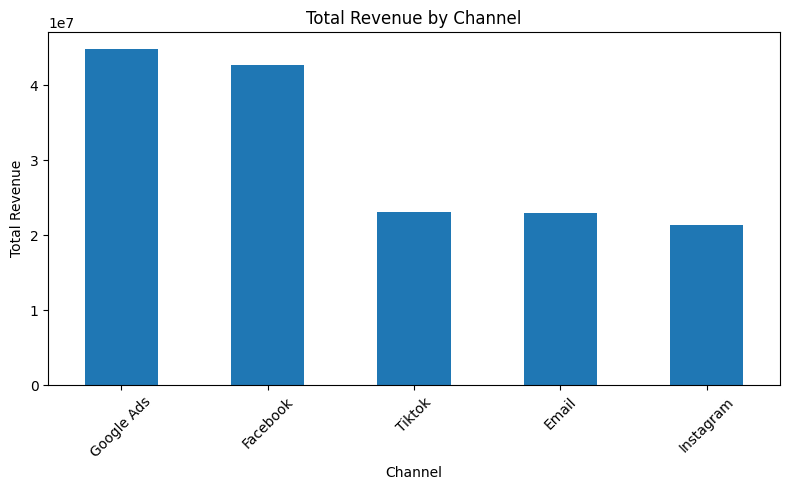

In [ ]:
revenue_by_channel = (
    campaign_df.groupby("Channel")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
revenue_by_channel.plot(kind="bar")

plt.title("Total Revenue by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

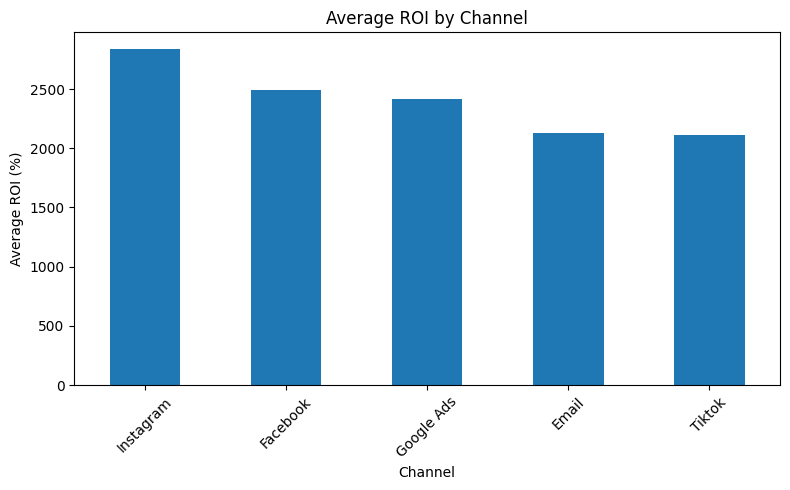

In [ ]:
avg_roi_by_channel = (
    campaign_df.groupby("Channel")["ROI"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
avg_roi_by_channel.plot(kind="bar")

plt.title("Average ROI by Channel")
plt.xlabel("Channel")
plt.ylabel("Average ROI (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

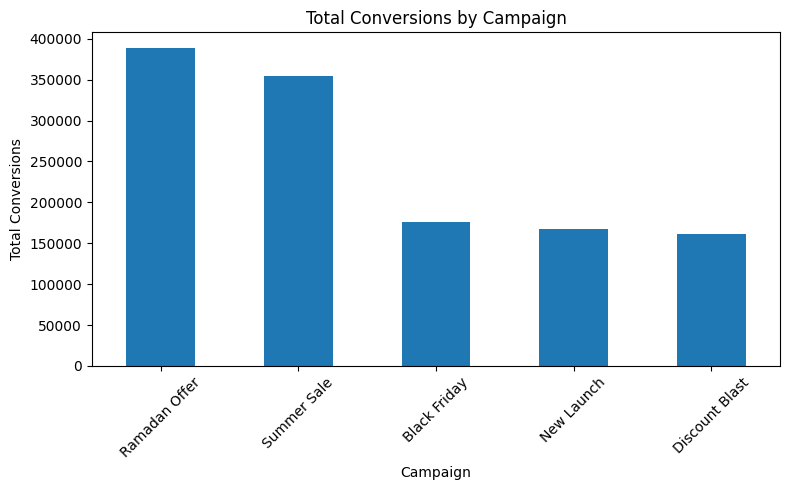

In [ ]:
conversions_by_campaign = (
    campaign_df.groupby("Campaign_Name")["Conversions"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
conversions_by_campaign.plot(kind="bar")

plt.title("Total Conversions by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Total Conversions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

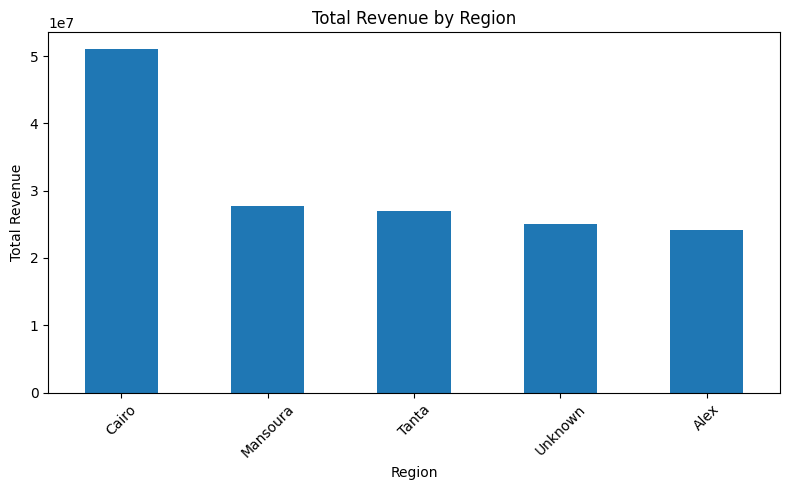

In [ ]:
revenue_by_region = (
    campaign_df.groupby("Region")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
revenue_by_region.plot(kind="bar")

plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

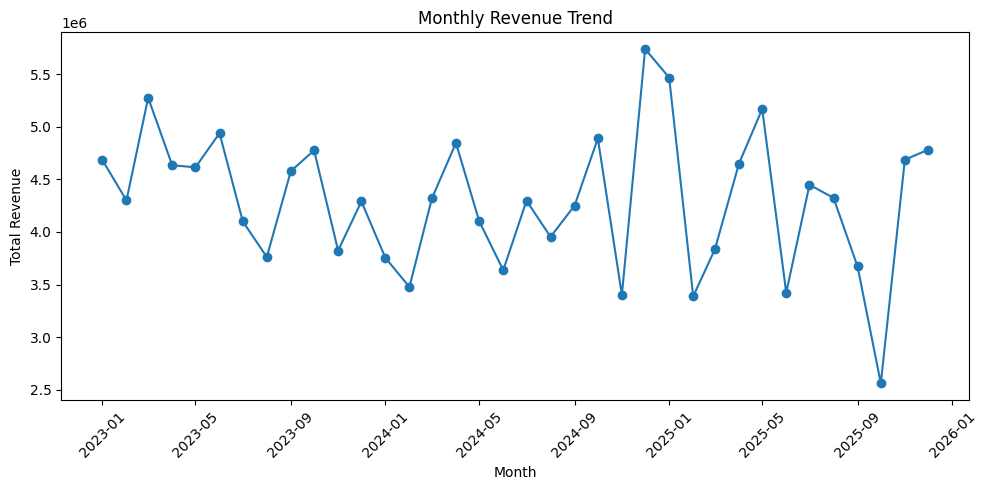

In [ ]:
campaign_df["Date"] = pd.to_datetime(
    campaign_df["Date"],
    errors="coerce"
)

monthly_revenue = (
    campaign_df
    .assign(Month=campaign_df["Date"].dt.to_period("M").dt.to_timestamp())
    .groupby("Month")["Revenue"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()